In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import process_data_model_2
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from scipy import stats

In [3]:
# Set display options and load data
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
data = pd.read_csv("data_with_full_climbing_vel.csv")
data = process_data_model_2(data)

Rows with nan features dropped: 2


In [4]:
categorical_variables = ['routeType', 'flightType', 'wake', 'RECATwake', 'numberOfEngines', 'aircraftType', 'airlineCode']
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.difference(categorical_variables)

## Correlation ratio (https://en.wikipedia.org/wiki/Correlation_ratio)

In [5]:
def correlation_ratio(categories, measurements):
    categories = np.asarray(categories)
    measurements = np.asarray(measurements)
    # Calculate means for each category
    cat_means = {category: measurements[categories == category].mean() 
                 for category in np.unique(categories)}
    # Overall mean of measurements
    overall_mean = measurements.mean()
    # Calculate the "between group" sum of squares
    sst = sum(((cat_means[category] - overall_mean) ** 2) * sum(categories == category) 
              for category in cat_means.keys())
    # Calculate the total sum of squares
    sstot = sum((measurement - overall_mean) ** 2 for measurement in measurements)
    # Return the correlation ratio
    return np.sqrt(sst / sstot)

In [6]:
correlation_matrix = pd.DataFrame(index=categorical_variables, columns=numeric_cols)
# Compute the correlation ratio for each pair
for cat in categorical_variables:
    for num in numeric_cols:
        try:
            correlation_matrix.loc[cat, num] = correlation_ratio(data[cat], data[num])
        except Exception:
            correlation_matrix.loc[cat, num] = np.nan
# Convert to float
correlation_matrix = correlation_matrix.T.astype(float)

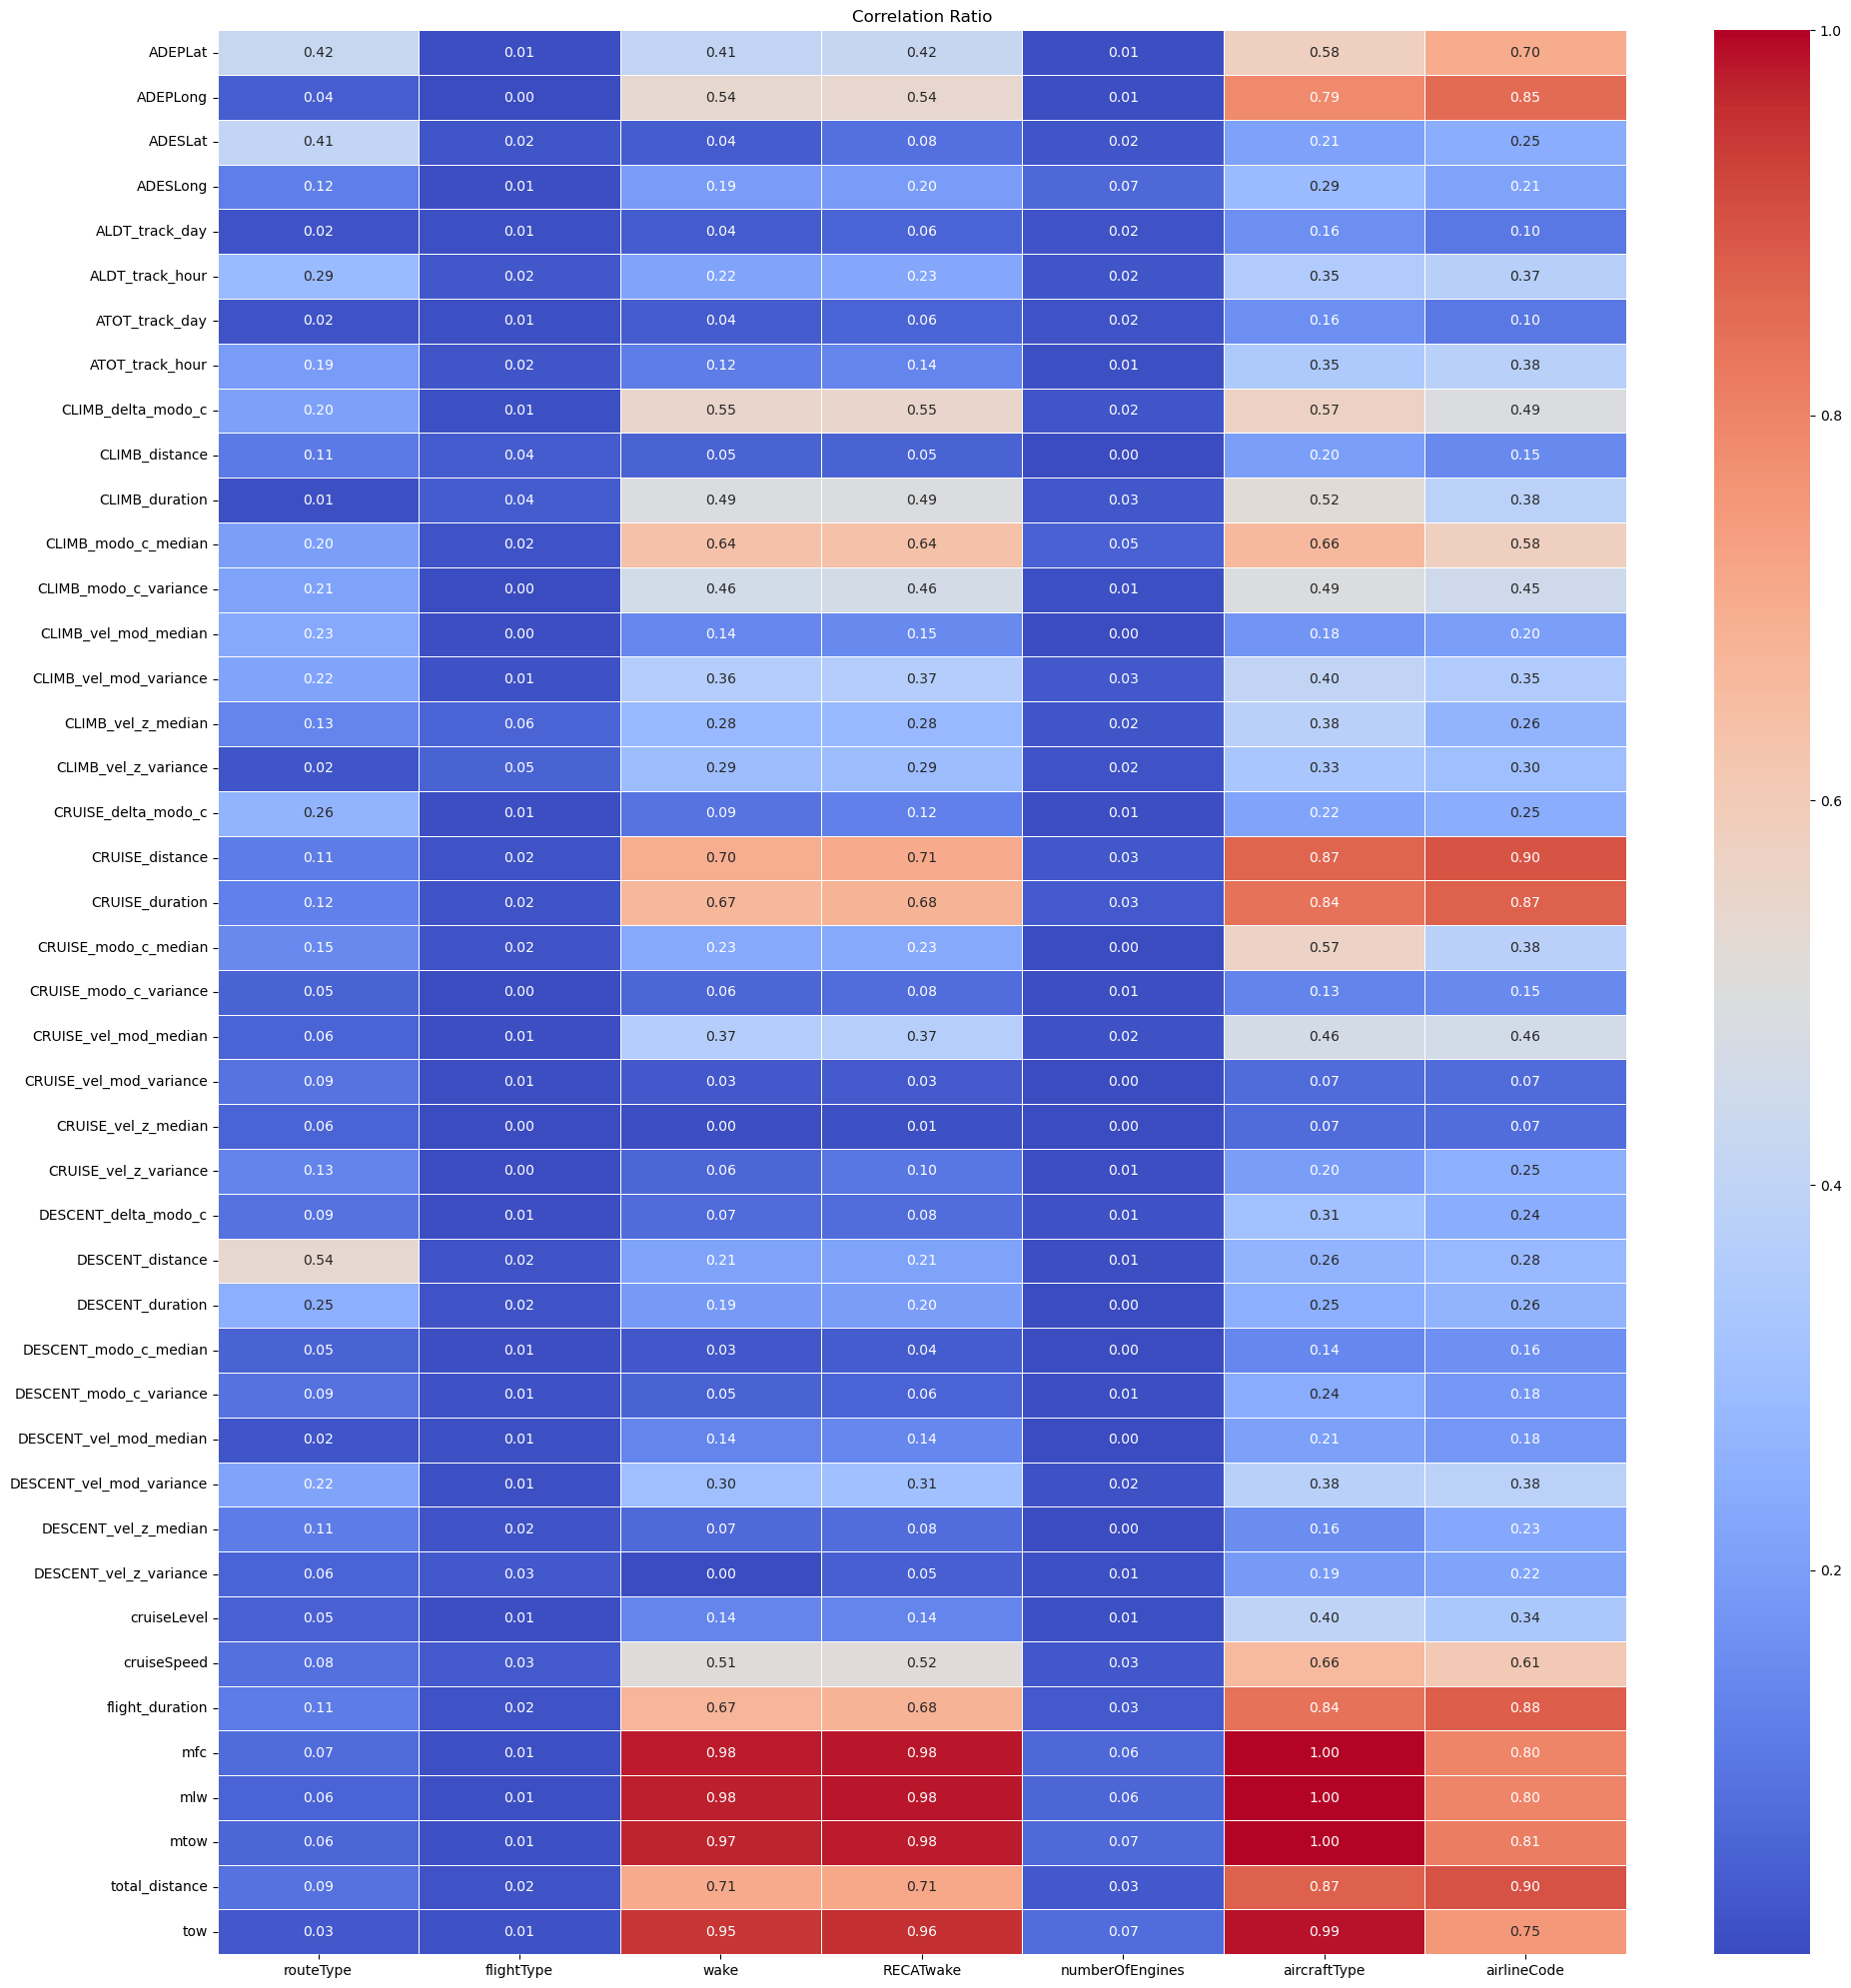

In [7]:
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, fmt=".2f", cmap='coolwarm', annot=True, linewidths=0.5)
plt.title('Correlation Ratio')
plt.tight_layout()
plt.show()

### >0.5 filter

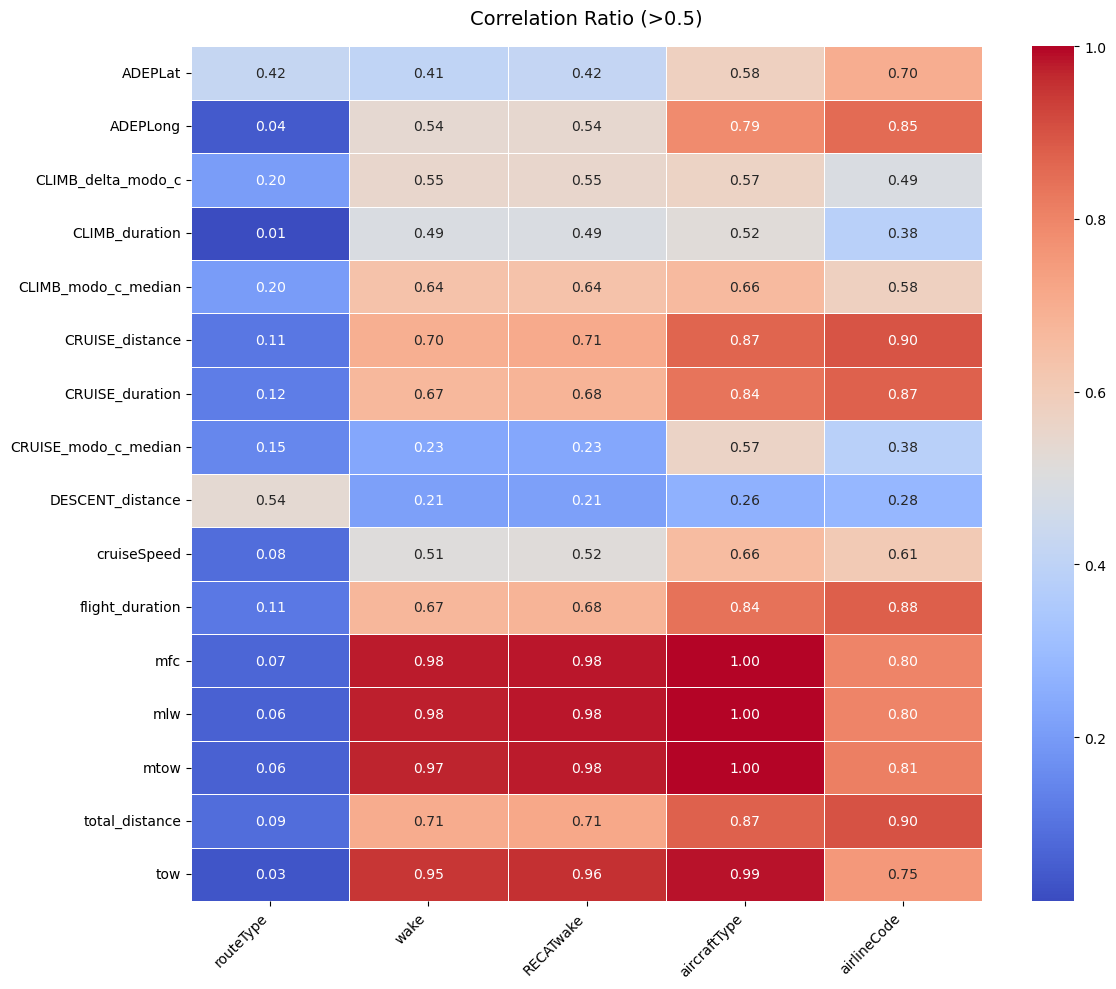

In [8]:
# --- 1) Threshold and filtering ---
threshold = 0.5

# Boolean masks for "any strong corr." per row and per column
rows_to_keep = (abs(correlation_matrix) >= threshold).any(axis=1)
cols_to_keep = (abs(correlation_matrix) >= threshold).any(axis=0)

# Subset the matrix
correlation_matrix_filtered = pd.DataFrame(index=rows_to_keep[rows_to_keep == True].index, columns=cols_to_keep[cols_to_keep == True].index)

for cat in cols_to_keep[cols_to_keep == True].index:
    for num in rows_to_keep[rows_to_keep == True].index:
        try:
            correlation_matrix_filtered.loc[num, cat] = correlation_ratio(data[cat], data[num])
        except Exception:
            correlation_matrix_filtered.loc[num, cat] = np.nan
            
correlation_matrix_filtered = correlation_matrix_filtered.astype(float)            

plt.figure(figsize=(12, 10))
plt.title(f"Correlation Ratio (>{threshold})", pad=16, fontsize=14)
sns.heatmap(correlation_matrix_filtered, fmt=".2f", cmap='coolwarm', annot=True, linewidths=0.5)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Point-biserial correlation coefficient (https://en.wikipedia.org/wiki/Point-biserial_correlation_coefficient)

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', list(numeric_cols)),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='error'), categorical_variables),
    ]
)

data_processed = preprocessor.fit_transform(data)

In [10]:
encoder = preprocessor.named_transformers_['cat']
data_processed_df = pd.DataFrame(
    data_processed, 
    columns=list(numeric_cols) + list(encoder.get_feature_names_out(categorical_variables)),
    index=data.index
)

In [11]:
encoded_categorical = [col for col in data_processed_df.columns if col not in numeric_cols]
pointbiserial_matrix = pd.DataFrame(index=encoded_categorical, columns=numeric_cols)

for cat in encoded_categorical:
    for num in numeric_cols:
        try:
            pointbiserial_matrix.loc[cat, num] = stats.pointbiserialr(data_processed_df[cat], data_processed_df[num])[0]
        except Exception:
            pointbiserial_matrix.loc[cat, num] = np.nan

# Convert to float
pointbiserial_matrix = pointbiserial_matrix.T.astype(float)

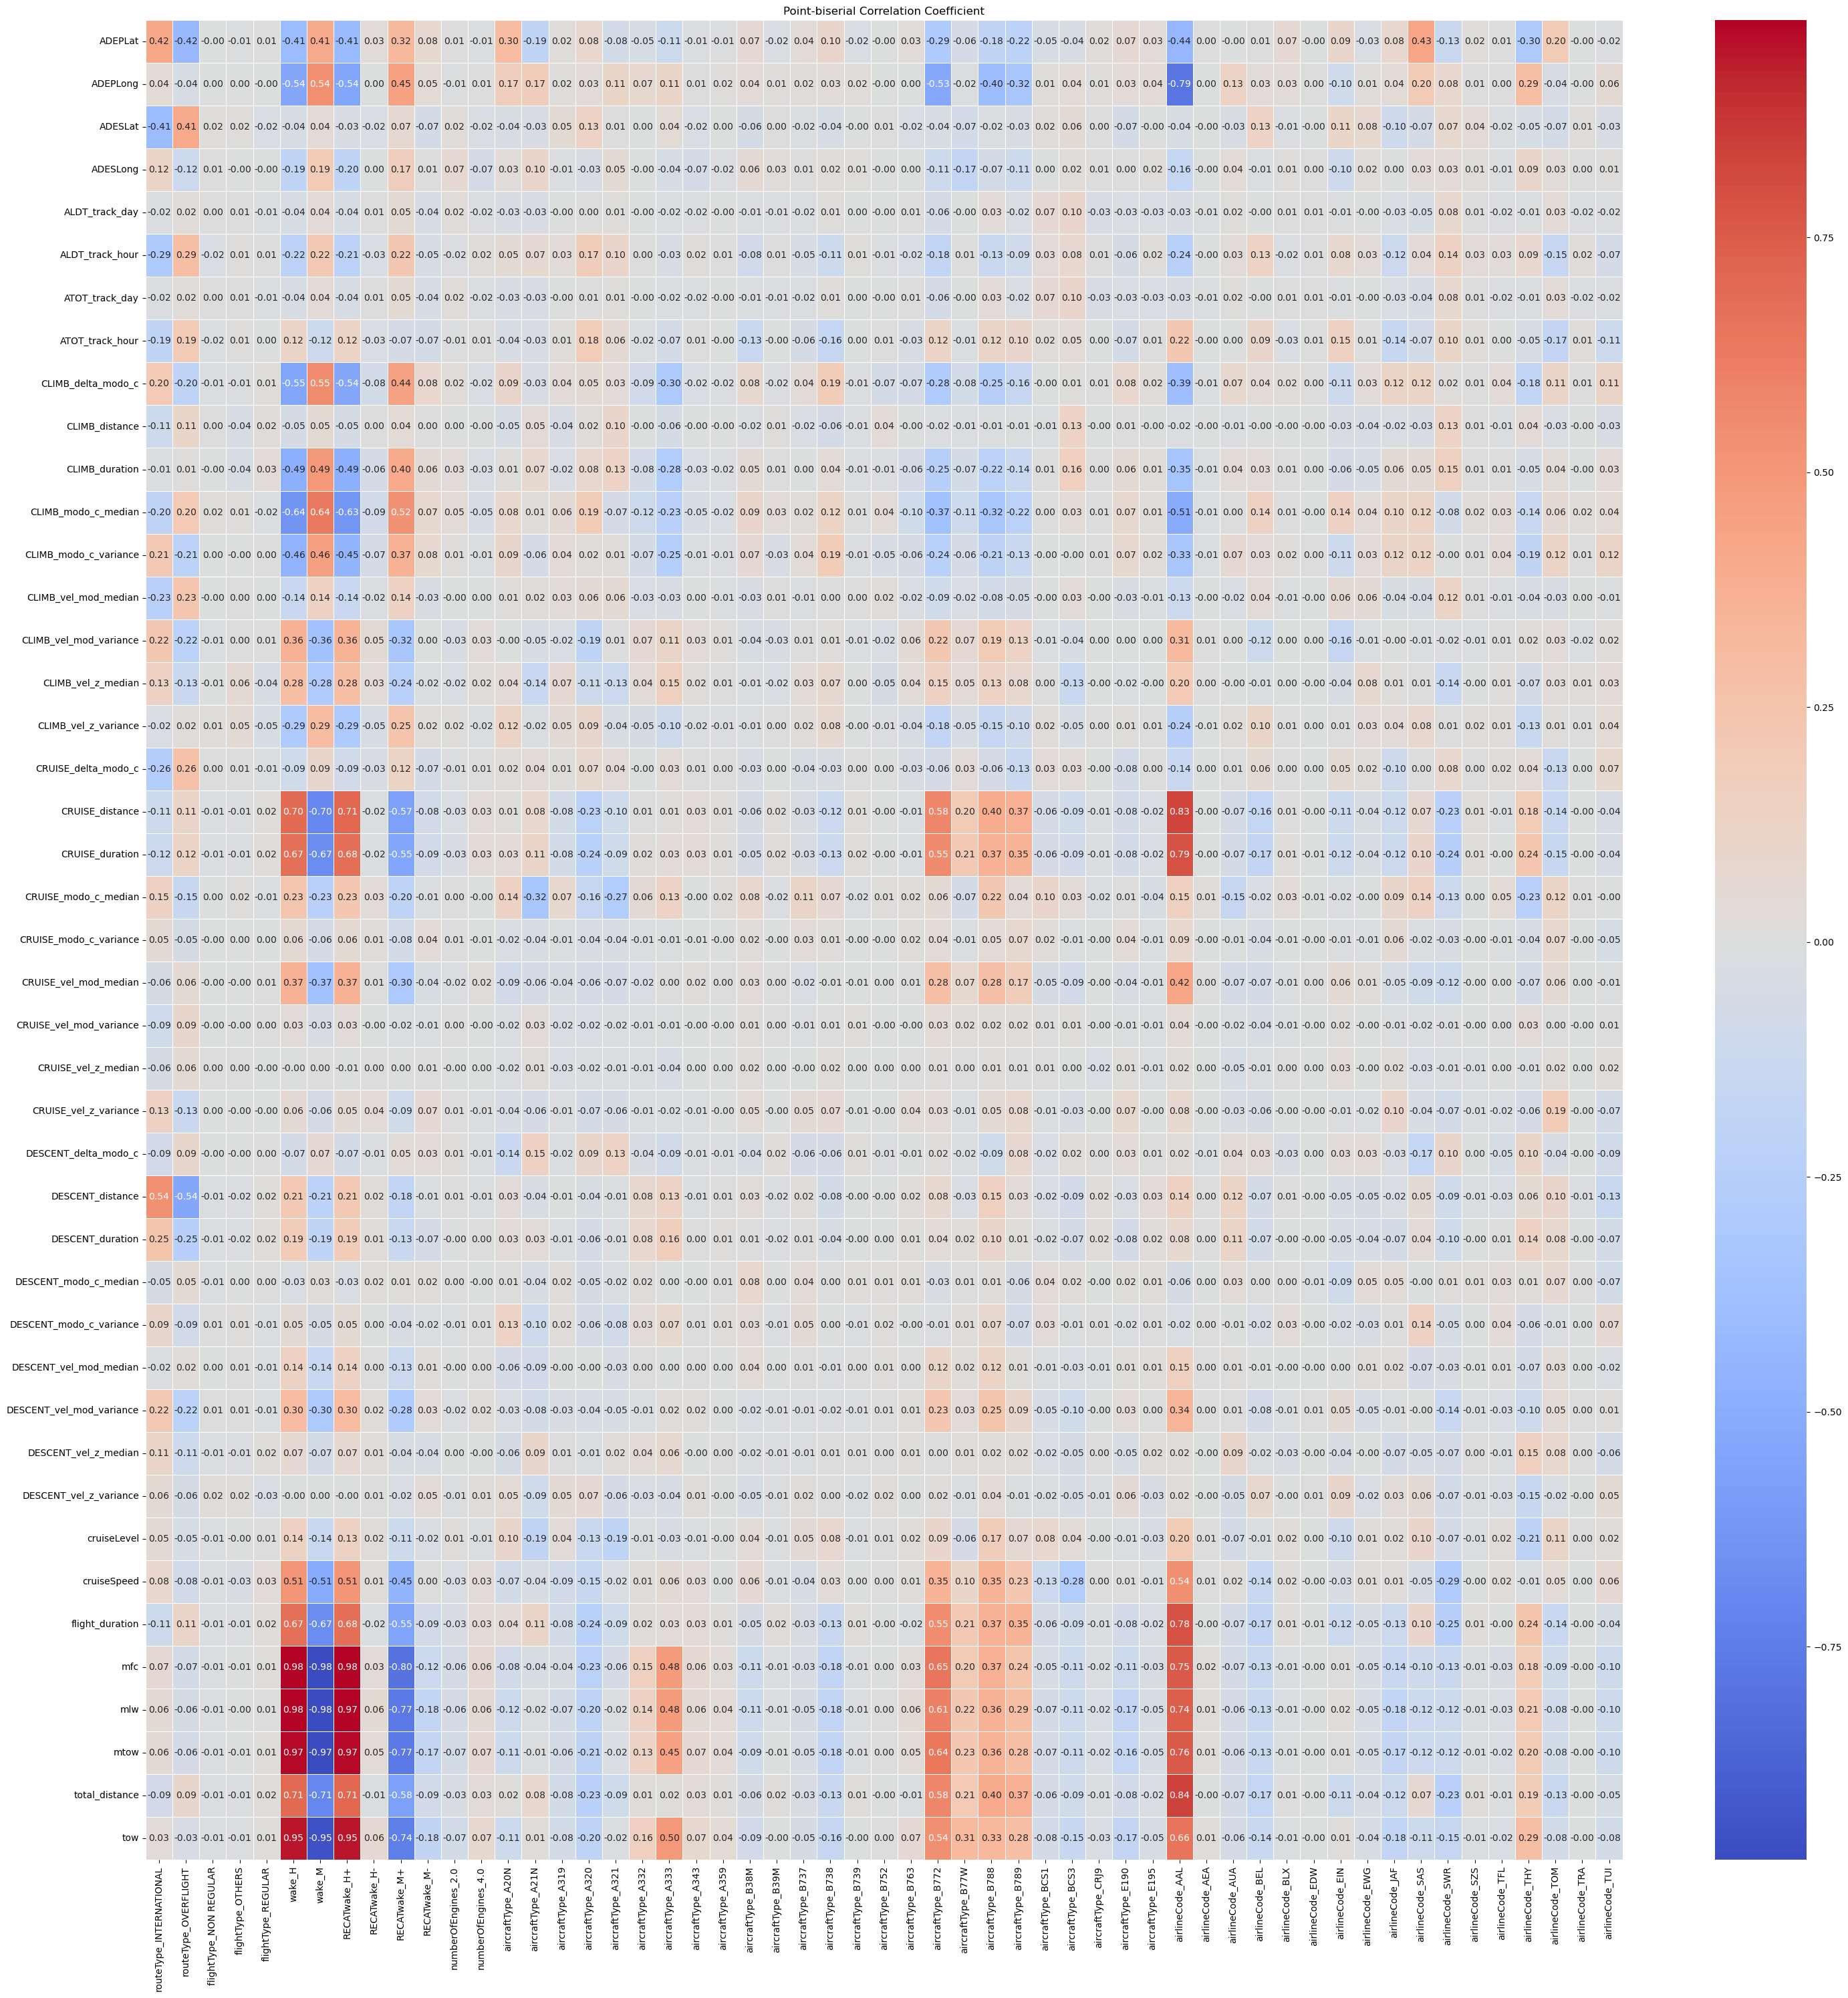

In [12]:
plt.figure(figsize=(30, 30))
sns.heatmap(pointbiserial_matrix, fmt=".2f", cmap='coolwarm', annot=True, linewidths=0.5)
plt.title('Point-biserial Correlation Coefficient')
plt.tight_layout()
plt.show()

### >|0.5| filter

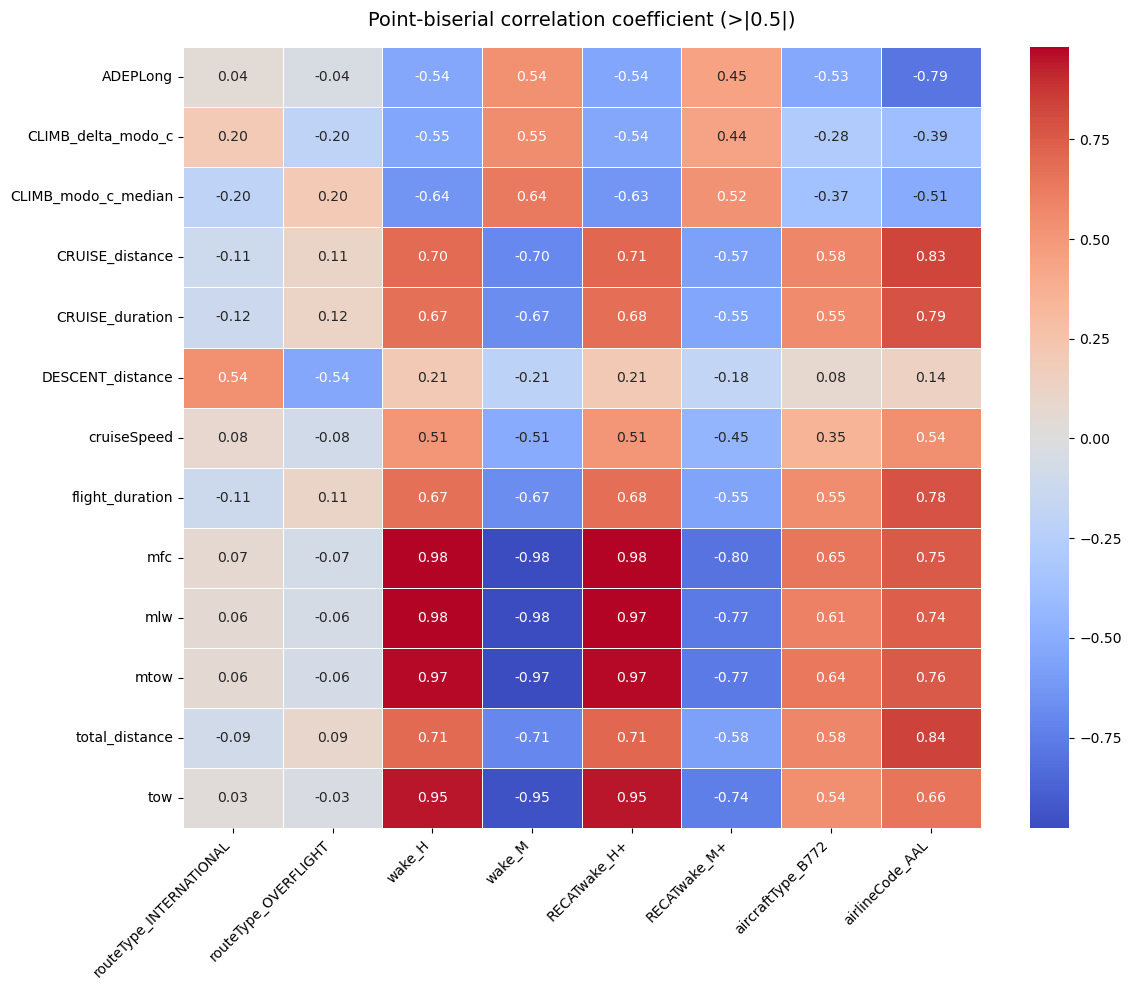

In [14]:
# --- 1) Threshold and filtering ---
threshold = 0.5

# Boolean masks for "any strong corr." per row and per column
rows_to_keep = (abs(pointbiserial_matrix) >= threshold).any(axis=1)
cols_to_keep = (abs(pointbiserial_matrix) >= threshold).any(axis=0)

# Subset the matrix
pointbiserial_matrix_filtered = pd.DataFrame(index=rows_to_keep[rows_to_keep == True].index, columns=cols_to_keep[cols_to_keep == True].index)

for cat in cols_to_keep[cols_to_keep == True].index:
    for num in rows_to_keep[rows_to_keep == True].index:
        try:
            pointbiserial_matrix_filtered.loc[num, cat] = stats.pointbiserialr(data_processed_df[cat], data_processed_df[num])[0]
        except Exception:
            pointbiserial_matrix_filtered.loc[num, cat] = np.nan
            
pointbiserial_matrix_filtered = pointbiserial_matrix_filtered.astype(float)            

plt.figure(figsize=(12, 10))
plt.title(f"Point-biserial correlation coefficient (>|{threshold}|)", pad=16, fontsize=14)
sns.heatmap(pointbiserial_matrix_filtered, fmt=".2f", cmap='coolwarm', annot=True, linewidths=0.5)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()